<a href="https://colab.research.google.com/github/aakash1552005/AAKASH-CLOTHING_WEBSITE/blob/main/Waste_Classifier_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🗑️ Waste Classifier — Training Notebook
### AI-Based Smart Garbage Segregation Bin (5 Categories)
**Project:** Smart Garbage Segregation Bin — Greater Chennai Corporation  
**Model:** MobileNetV2 Transfer Learning → `waste_classifier.h5`  
**Categories:** `0=Wet` | `1=Dry` | `2=Plastic` | `3=Biomedical` | `4=Recyclable`  
**Dataset:** Garbage Classification 12-class (Kaggle) → remapped to 5 bins  

---
### 📋 Instructions
1. Go to **Runtime → Change runtime type → T4 GPU** before running
2. Run all cells top to bottom (Ctrl+F9)
3. Download `waste_classifier.h5` from the last cell → put it next to `laptop_server.py`


## Cell 1 — Install & Import

In [ ]:
# Install any missing packages
!pip install -q kaggle tensorflow matplotlib seaborn scikit-learn

import os, shutil, random, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")


TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — Kaggle API Setup
**How to get your kaggle.json:**
1. Go to https://www.kaggle.com → Your Profile → Settings → API → Create New Token
2. It downloads `kaggle.json` automatically
3. Upload it when the cell below asks for it


In [ ]:
from google.colab import files

print("Upload your kaggle.json file now...")
uploaded = files.upload()  # upload kaggle.json here

# Place kaggle.json in the right location
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "wb") as f:
    f.write(uploaded["kaggle.json"])
os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("✓ kaggle.json configured successfully")


Upload your kaggle.json file now...


Saving kaggle.json to kaggle.json
✓ kaggle.json configured successfully


## Cell 3 — Download Dataset from Kaggle

In [ ]:
# Download the 12-class Garbage Classification dataset (~190MB, ~15k images)
!kaggle datasets download -d mostafaabla/garbage-classification -p /content/raw --unzip --quiet
print("✓ Dataset downloaded")

# Also download Pharmaceutical & Biomedical Waste dataset
!kaggle datasets download -d engineeringubu/pharmaceutical-and-biomedical-waste -p /content/raw_bio --unzip --quiet
print("✓ Biomedical dataset downloaded")

# List what we got
import glob
print("\n── 12-class dataset structure ──")
for d in sorted(glob.glob("/content/raw/garbage_classification/*")):
    n = len(glob.glob(d + "/*"))
    print(f"  {os.path.basename(d):20s} → {n} images")


Dataset URL: https://www.kaggle.com/datasets/mostafaabla/garbage-classification
License(s): ODbL-1.0
✓ Dataset downloaded
Dataset URL: https://www.kaggle.com/datasets/engineeringubu/pharmaceutical-and-biomedical-waste
License(s): CC-BY-NC-SA-4.0
✓ Biomedical dataset downloaded

── 12-class dataset structure ──
  battery              → 945 images
  biological           → 985 images
  brown-glass          → 607 images
  cardboard            → 891 images
  clothes              → 5325 images
  green-glass          → 629 images
  metal                → 769 images
  paper                → 1050 images
  plastic              → 865 images
  shoes                → 1977 images
  trash                → 697 images
  white-glass          → 775 images


## Cell 4 — Remap 12 Classes → 5 Bins
| Original 12 classes | → Our 5 bins |
|---|---|
| biological | WET (0) |
| paper, cardboard, clothes, shoes, trash | DRY (1) |
| plastic | PLASTIC (2) |
| batteries + pharma/biomedical images | BIOMEDICAL (3) |
| metal, green-glass, brown-glass, white-glass | RECYCLABLE (4) |


In [ ]:
# ── Category Mapping ──────────────────────────────────────────────────────────
CLASS_NAMES = ["wet", "dry", "plastic", "biomedical", "recyclable"]

REMAP = {
    "biological"  : "wet",
    "paper"       : "dry",
    "cardboard"   : "dry",
    "clothes"     : "dry",
    "shoes"       : "dry",
    "trash"       : "dry",
    "plastic"     : "plastic",
    "batteries"   : "biomedical",
    "metal"       : "recyclable",
    "green-glass" : "recyclable",
    "brown-glass" : "recyclable",
    "white-glass" : "recyclable",
}

# ── Build re-mapped dataset directories ───────────────────────────────────────
DATASET_DIR = "/content/dataset"
for split in ["train", "val"]:
    for cls in CLASS_NAMES:
        os.makedirs(f"{DATASET_DIR}/{split}/{cls}", exist_ok=True)

SOURCE_DIR = "/content/raw/garbage_classification"

# 80/20 split within each original class → remap into our 5 bins
random.seed(42)
counts = {c: 0 for c in CLASS_NAMES}

for orig_cls, target_cls in REMAP.items():
    src = os.path.join(SOURCE_DIR, orig_cls)
    if not os.path.isdir(src):
        print(f"  ⚠ Not found: {orig_cls} — skipping")
        continue
    imgs = sorted(os.listdir(src))
    random.shuffle(imgs)
    split_idx = int(0.8 * len(imgs))
    for i, img in enumerate(imgs):
        split = "train" if i < split_idx else "val"
        dst = f"{DATASET_DIR}/{split}/{target_cls}/{orig_cls}_{img}"
        shutil.copy2(os.path.join(src, img), dst)
    counts[target_cls] += len(imgs)
    print(f"  ✓ {orig_cls:15s} ({len(imgs):4d}) → {target_cls}")

# ── Add biomedical images from pharmaceutical dataset ─────────────────────────
bio_src = "/content/raw_bio"
bio_imgs = glob.glob(f"{bio_src}/**/*.jpg", recursive=True) +            glob.glob(f"{bio_src}/**/*.jpeg", recursive=True) +            glob.glob(f"{bio_src}/**/*.png",  recursive=True)
random.shuffle(bio_imgs)
split_idx = int(0.8 * len(bio_imgs))
for i, p in enumerate(bio_imgs):
    split = "train" if i < split_idx else "val"
    dst = f"{DATASET_DIR}/{split}/biomedical/pharma_{i:05d}{os.path.splitext(p)[1]}"
    shutil.copy2(p, dst)
counts["biomedical"] += len(bio_imgs)
print(f"  ✓ {'pharma/biomedical':15s} ({len(bio_imgs):4d}) → biomedical")

print("\n── Final class totals ──")
for c, n in counts.items():
    bar = "█" * (n // 100)
    print(f"  {c:12s} : {n:5d} images  {bar}")


  ✓ biological      ( 985) → wet
  ✓ paper           (1050) → dry
  ✓ cardboard       ( 891) → dry
  ✓ clothes         (5325) → dry
  ✓ shoes           (1977) → dry
  ✓ trash           ( 697) → dry
  ✓ plastic         ( 865) → plastic
  ⚠ Not found: batteries — skipping
  ✓ metal           ( 769) → recyclable
  ✓ green-glass     ( 629) → recyclable
  ✓ brown-glass     ( 607) → recyclable
  ✓ white-glass     ( 775) → recyclable
  ✓ pharma/biomedical (6156) → biomedical

── Final class totals ──
  wet          :   985 images  █████████
  dry          :  9940 images  ███████████████████████████████████████████████████████████████████████████████████████████████████
  plastic      :   865 images  ████████
  biomedical   :  6156 images  █████████████████████████████████████████████████████████████
  recyclable   :  2780 images  ███████████████████████████


## Cell 5 — Visualise Sample Images

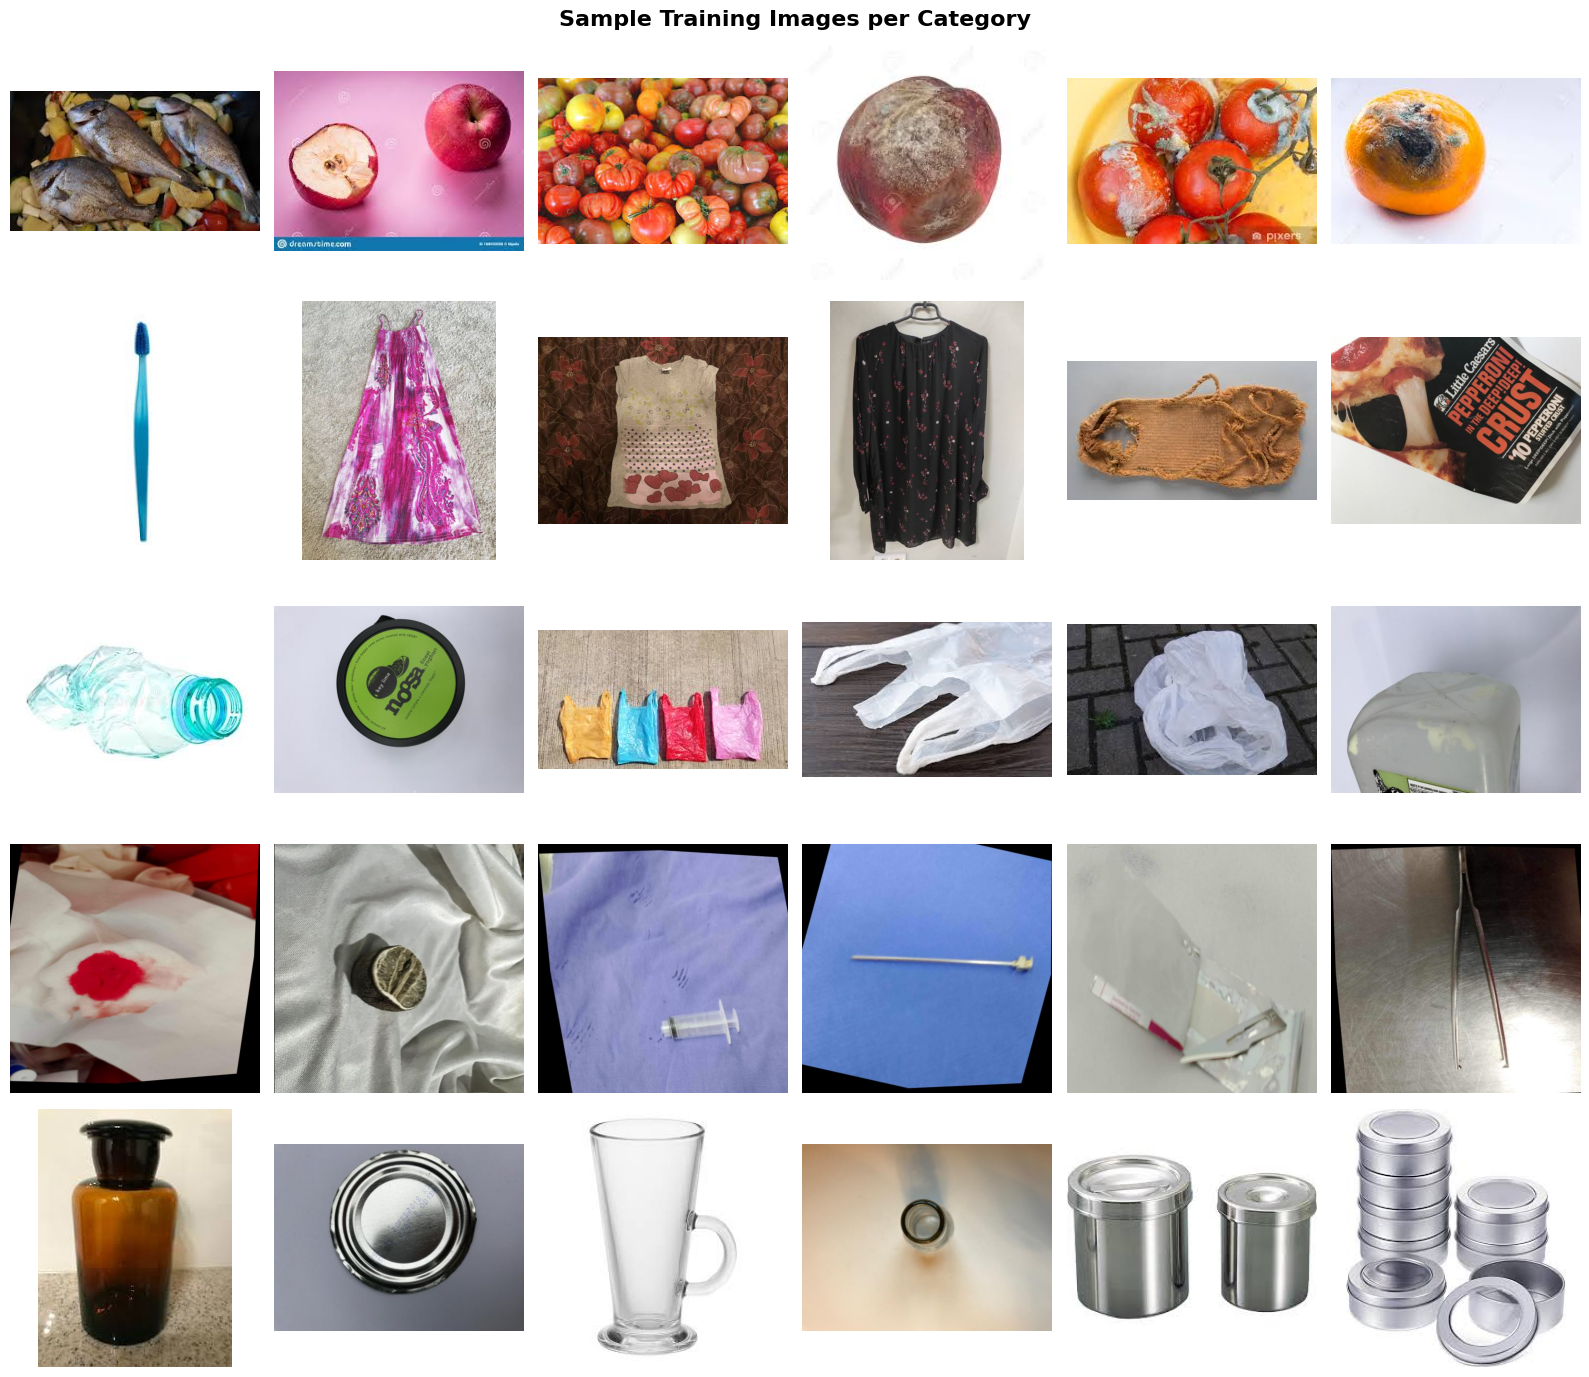

✓ Sample images saved to /content/sample_images.png


In [ ]:
fig, axes = plt.subplots(5, 6, figsize=(16, 14))
fig.suptitle("Sample Training Images per Category", fontsize=16, fontweight="bold")
colors = ["#1E88E5","#43A047","#FB8C00","#E53935","#8E24AA"]

for row, cls in enumerate(CLASS_NAMES):
    imgs = glob.glob(f"{DATASET_DIR}/train/{cls}/*.jpg")[:6] +            glob.glob(f"{DATASET_DIR}/train/{cls}/*.jpeg")[:6] +            glob.glob(f"{DATASET_DIR}/train/{cls}/*.png")[:6]
    random.shuffle(imgs)
    for col in range(6):
        ax = axes[row][col]
        if col < len(imgs):
            img = plt.imread(imgs[col])
            ax.imshow(img)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(cls.upper(), fontsize=11, fontweight="bold",
                          color=colors[row], rotation=90, labelpad=10)
plt.tight_layout()
plt.savefig("/content/sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Sample images saved to /content/sample_images.png")


## Cell 6 — Data Augmentation & Generators

In [ ]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# ── Training augmentation (makes model robust to real-world variation) ──────
train_aug = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 20,
    width_shift_range  = 0.15,
    height_shift_range = 0.15,
    shear_range        = 0.1,
    zoom_range         = 0.2,
    horizontal_flip    = True,
    brightness_range   = [0.6, 1.4],  # important for flash-lit chute images
    fill_mode          = "nearest"
)

# ── Validation: only rescale (no augmentation) ────────────────────────────────
val_aug = ImageDataGenerator(rescale=1./255)

train_gen = train_aug.flow_from_directory(
    f"{DATASET_DIR}/train",
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = "categorical",
    classes      = CLASS_NAMES,
    shuffle      = True,
    seed         = 42
)

val_gen = val_aug.flow_from_directory(
    f"{DATASET_DIR}/val",
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = "categorical",
    classes      = CLASS_NAMES,
    shuffle      = False
)

print(f"\nClass indices: {train_gen.class_indices}")
print(f"Train batches : {len(train_gen)}")
print(f"Val   batches : {len(val_gen)}")

# ── Compute class weights (handles imbalance between categories) ──────────────
labels = train_gen.classes
class_weights_arr = compute_class_weight("balanced", classes=np.unique(labels), y=labels)
class_weights = {i: w for i, w in enumerate(class_weights_arr)}
print(f"\nClass weights (imbalance correction):")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:12s} → {class_weights[i]:.3f}")


Found 16577 images belonging to 5 classes.
Found 4149 images belonging to 5 classes.

Class indices: {'wet': 0, 'dry': 1, 'plastic': 2, 'biomedical': 3, 'recyclable': 4}
Train batches : 519
Val   batches : 130

Class weights (imbalance correction):
  wet          → 4.207
  dry          → 0.417
  plastic      → 4.791
  biomedical   → 0.673
  recyclable   → 1.491


## Cell 7 — Build MobileNetV2 Model
**Why MobileNetV2?**
- Lightweight (~14MB) — fast to load on laptop
- Pretrained on ImageNet → already knows shapes, textures, colours
- Strong accuracy on waste classification tasks


In [ ]:
def build_model(num_classes=5, trainable_base=False):
    base = MobileNetV2(
        input_shape  = (*IMG_SIZE, 3),
        include_top  = False,
        weights      = "imagenet"
    )
    base.trainable = trainable_base

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model, base

model, base_model = build_model(trainable_base=False)

model.compile(
    optimizer = optimizers.Adam(learning_rate=1e-3),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"]
)

model.summary()
print(f"\nTotal params      : {model.count_params():,}")
print(f"Trainable params  : {sum(np.prod(v.shape) for v in model.trainable_variables):,}")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,581 (10.01 MB)

 Trainable params: 364,037 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


Total params      : 2,624,581
Trainable params  : 364,037


## Cell 8 — Phase 1: Train Classifier Head (Base Frozen)
Train only the top Dense layers first. Base stays frozen.  
~10 epochs, fast convergence.


In [ ]:
PHASE1_EPOCHS = 12

cb_p1 = [
    callbacks.EarlyStopping(monitor="val_accuracy", patience=4,
                             restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=2, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint("/content/best_phase1.keras",
                               monitor="val_accuracy", save_best_only=True, verbose=0)
]

print("=" * 55)
print("  PHASE 1: Training classifier head (base FROZEN)")
print("=" * 55)

history1 = model.fit(
    train_gen,
    epochs          = PHASE1_EPOCHS,
    validation_data = val_gen,
    class_weight    = class_weights,
    callbacks       = cb_p1,
    verbose         = 1
)

best_p1_acc = max(history1.history["val_accuracy"])
print(f"\n✓ Phase 1 best val accuracy: {best_p1_acc*100:.2f}%")


  PHASE 1: Training classifier head (base FROZEN)
Epoch 1/12
519/519 ━━━━━━━━━━━━━━━━━━━━ 295s 527ms/step - accuracy: 0.8017 - loss: 0.5814 - val_accuracy: 0.9229 - val_loss: 0.2010 - learning_rate: 0.0010
Epoch 2/12
519/519 ━━━━━━━━━━━━━━━━━━━━ 236s 454ms/step - accuracy: 0.8757 - loss: 0.3673 - val_accuracy: 0.9436 - val_loss: 0.1496 - learning_rate: 0.0010
Epoch 3/12
519/519 ━━━━━━━━━━━━━━━━━━━━ 236s 455ms/step - accuracy: 0.8933 - loss: 0.3152 - val_accuracy: 0.9431 - val_loss: 0.1549 - learning_rate: 0.0010
Epoch 4/12
519/519 ━━━━━━━━━━━━━━━━━━━━ 235s 453ms/step - accuracy: 0.9011 - loss: 0.2844 - val_accuracy: 0.9448 - val_loss: 0.1381 - learning_rate: 0.0010
Epoch 5/12
519/519 ━━━━━━━━━━━━━━━━━━━━ 238s 459ms/step - accuracy: 0.9111 - loss: 0.2665 - val_accuracy: 0.9424 - val_loss: 0.1500 - learning_rate: 0.0010
Epoch 6/12
519/519 ━━━━━━━━━━━━━━━━━━━━ 234s 452ms/step - accuracy: 0.9149 - loss: 0.2470 - val_accuracy: 0.9583 - val_loss: 0.1095 - learning_rate: 0.0010
Epoch 7/12
519

## Cell 9 — Phase 1 Training Curves

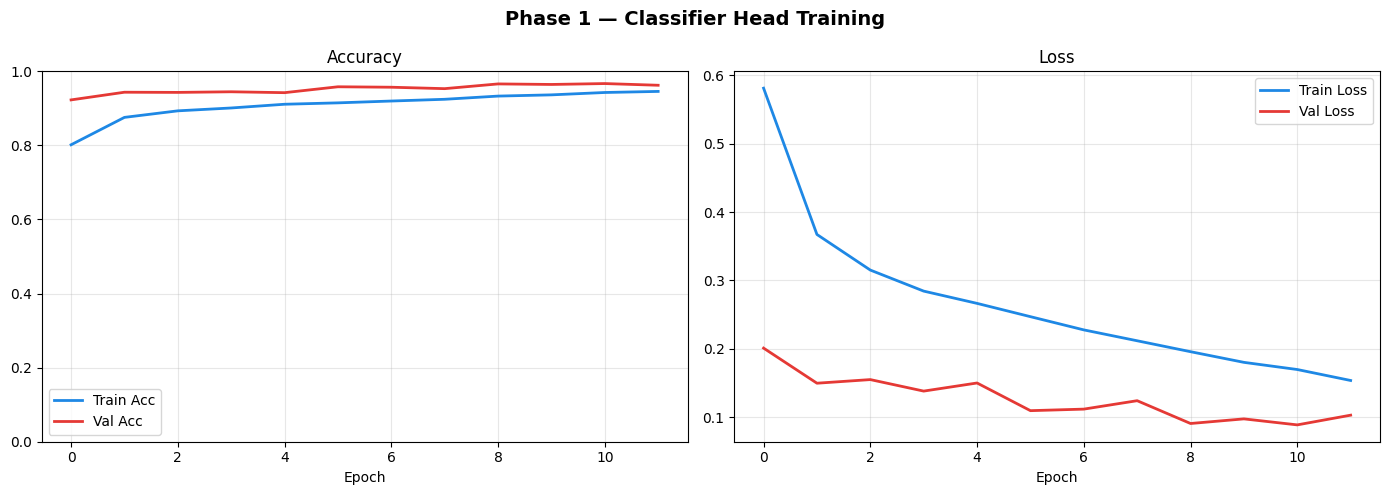

In [ ]:
def plot_history(h, title, path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight="bold")
    ax1.plot(h["accuracy"],     label="Train Acc",  color="#1E88E5", lw=2)
    ax1.plot(h["val_accuracy"], label="Val Acc",    color="#E53935", lw=2)
    ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend()
    ax1.set_ylim([0, 1]); ax1.grid(alpha=0.3)
    ax2.plot(h["loss"],         label="Train Loss", color="#1E88E5", lw=2)
    ax2.plot(h["val_loss"],     label="Val Loss",   color="#E53935", lw=2)
    ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend()
    ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

plot_history(history1.history,
             "Phase 1 — Classifier Head Training",
             "/content/phase1_curves.png")


## Cell 10 — Phase 2: Fine-Tune (Unfreeze Top Layers)
Unfreeze the last 30 layers of MobileNetV2 and train with a very small learning rate.  
This squeezes out extra accuracy by adapting ImageNet features to waste images.


In [ ]:
# Unfreeze last 30 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers after unfreeze: {trainable_count}")

# Recompile with much lower LR
model.compile(
    optimizer = optimizers.Adam(learning_rate=1e-5),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"]
)

PHASE2_EPOCHS = 20

cb_p2 = [
    callbacks.EarlyStopping(monitor="val_accuracy", patience=6,
                             restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3,
                                patience=3, min_lr=1e-8, verbose=1),
    callbacks.ModelCheckpoint("/content/best_phase2.keras",
                               monitor="val_accuracy", save_best_only=True, verbose=0)
]

print("=" * 55)
print("  PHASE 2: Fine-tuning top layers (base PARTIAL)")
print("=" * 55)

history2 = model.fit(
    train_gen,
    epochs          = PHASE2_EPOCHS,
    validation_data = val_gen,
    class_weight    = class_weights,
    callbacks       = cb_p2,
    verbose         = 1
)

best_p2_acc = max(history2.history["val_accuracy"])
print(f"\n✓ Phase 2 best val accuracy: {best_p2_acc*100:.2f}%")


Trainable layers after unfreeze: 8
  PHASE 2: Fine-tuning top layers (base PARTIAL)
Epoch 1/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 274s 493ms/step - accuracy: 0.9026 - loss: 0.2984 - val_accuracy: 0.9549 - val_loss: 0.1237 - learning_rate: 1.0000e-05
Epoch 2/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 238s 459ms/step - accuracy: 0.9181 - loss: 0.2257 - val_accuracy: 0.9569 - val_loss: 0.1087 - learning_rate: 1.0000e-05
Epoch 3/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 243s 469ms/step - accuracy: 0.9266 - loss: 0.1972 - val_accuracy: 0.9588 - val_loss: 0.1083 - learning_rate: 1.0000e-05
Epoch 4/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 251s 483ms/step - accuracy: 0.9295 - loss: 0.1878 - val_accuracy: 0.9607 - val_loss: 0.1094 - learning_rate: 1.0000e-05
Epoch 5/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 255s 491ms/step - accuracy: 0.9327 - loss: 0.1735 - val_accuracy: 0.9617 - val_loss: 0.1024 - learning_rate: 1.0000e-05
Epoch 6/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 242s 466ms/step - accuracy: 0.9408 - loss: 0.1576 - val_accuracy: 0.9655 - v

## Cell 11 — Phase 2 Training Curves

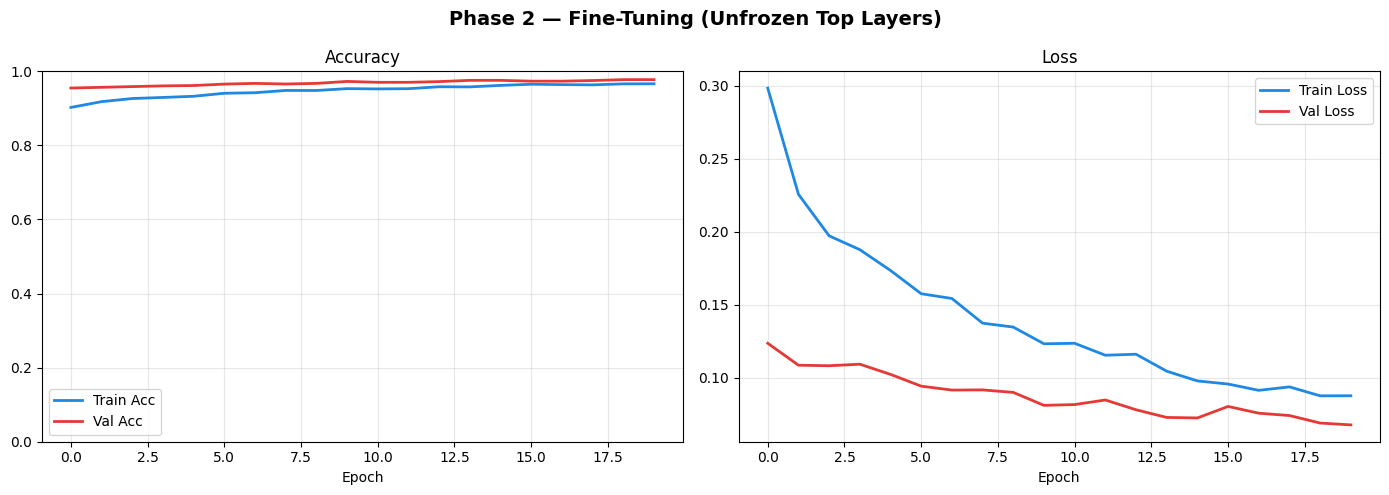

In [ ]:
plot_history(history2.history,
             "Phase 2 — Fine-Tuning (Unfrozen Top Layers)",
             "/content/phase2_curves.png")


## Cell 12 — Evaluate on Validation Set

130/130 ━━━━━━━━━━━━━━━━━━━━ 17s 100ms/step

  CLASSIFICATION REPORT
              precision    recall  f1-score   support

         wet      0.975     0.975     0.975       197
         dry      0.995     0.975     0.985      1990
     plastic      0.850     0.919     0.883       173
  biomedical      0.987     1.000     0.994      1232
  recyclable      0.938     0.955     0.947       557

    accuracy                          0.978      4149
   macro avg      0.949     0.965     0.957      4149
weighted avg      0.978     0.978     0.978      4149



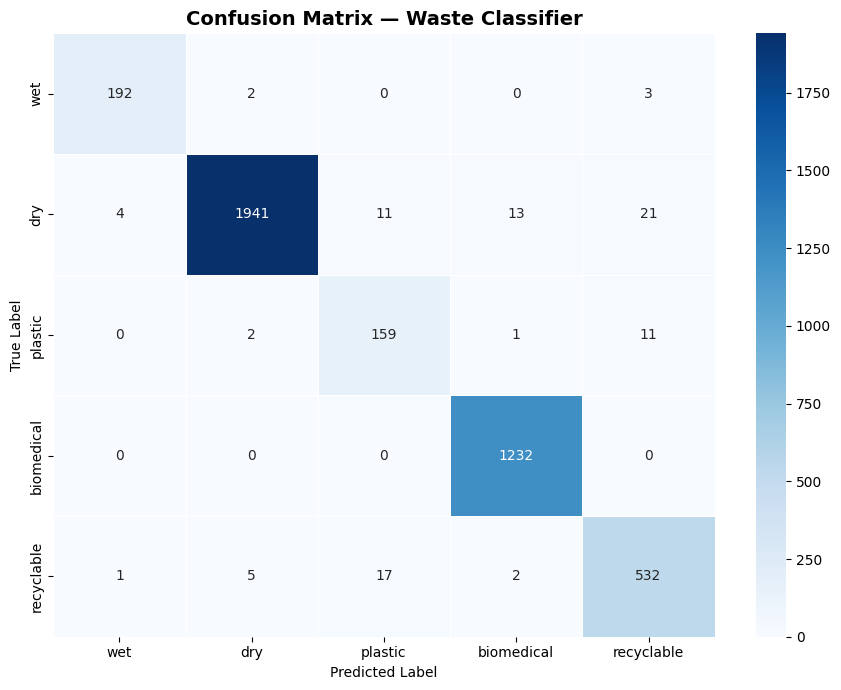


✓ Overall Validation Accuracy: 97.76%


In [ ]:
val_gen.reset()
preds       = model.predict(val_gen, verbose=1)
pred_labels = np.argmax(preds, axis=1)
true_labels = val_gen.classes

# ── Classification Report ────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(true_labels, pred_labels,
                              target_names=CLASS_NAMES, digits=3))

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5)
plt.title("Confusion Matrix — Waste Classifier", fontsize=14, fontweight="bold")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

overall_acc = np.sum(np.diag(cm)) / np.sum(cm) * 100
print(f"\n✓ Overall Validation Accuracy: {overall_acc:.2f}%")


## Cell 13 — Save Model as `waste_classifier.h5`
This is the file your `laptop_server.py` loads.


In [ ]:
MODEL_PATH = "/content/waste_classifier.h5"
model.save(MODEL_PATH)
print(f"✓ Model saved: {MODEL_PATH}")

size_mb = os.path.getsize(MODEL_PATH) / 1e6
print(f"  File size   : {size_mb:.1f} MB")
print(f"  Input shape : {model.input_shape}")
print(f"  Output shape: {model.output_shape}")
print(f"  Classes     : {CLASS_NAMES}")

# Save class names alongside the model
with open("/content/class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f)
print("✓ class_names.json saved")


✓ Model saved: /content/waste_classifier.h5
  File size   : 26.0 MB
  Input shape : (None, 224, 224, 3)
  Output shape: (None, 5)
  Classes     : ['wet', 'dry', 'plastic', 'biomedical', 'recyclable']
✓ class_names.json saved


## Cell 14 — Quick Inference Test

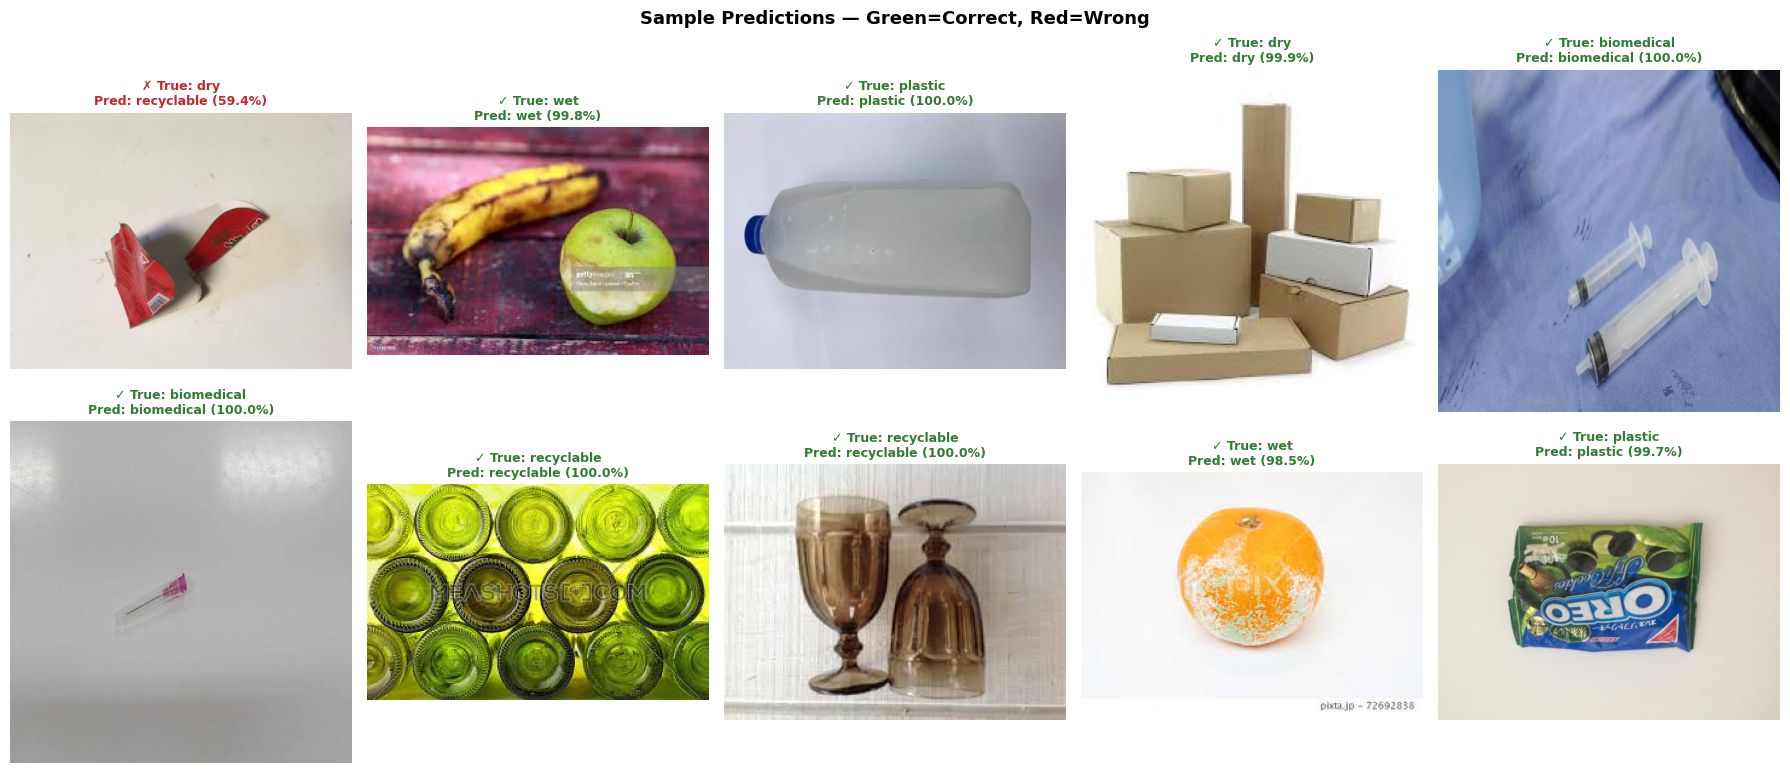

In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_image(img_path, model, class_names, img_size=(224,224)):
    img  = keras_image.load_img(img_path, target_size=img_size)
    arr  = keras_image.img_to_array(img) / 255.0
    arr  = np.expand_dims(arr, 0)
    pred = model.predict(arr, verbose=0)[0]
    idx  = np.argmax(pred)
    return class_names[idx], pred[idx]*100, pred

# Test on a few random validation images
val_gen.reset()
test_imgs = []
for cls in CLASS_NAMES:
    imgs = glob.glob(f"{DATASET_DIR}/val/{cls}/*.jpg")[:2]
    test_imgs.extend([(p, cls) for p in imgs])
random.shuffle(test_imgs)
test_imgs = test_imgs[:10]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()
colors = ["#1E88E5","#43A047","#FB8C00","#E53935","#8E24AA"]
cat_color = {c:col for c,col in zip(CLASS_NAMES, colors)}

for ax, (path, true_cls) in zip(axes, test_imgs):
    pred_cls, conf, probs = predict_image(path, model, CLASS_NAMES)
    img = plt.imread(path)
    ax.imshow(img)
    correct = (pred_cls == true_cls)
    title_color = "#2E7D32" if correct else "#C62828"
    marker = "✓" if correct else "✗"
    ax.set_title(f"{marker} True: {true_cls}\nPred: {pred_cls} ({conf:.1f}%)",
                  fontsize=9, color=title_color, fontweight="bold")
    ax.axis("off")

plt.suptitle("Sample Predictions — Green=Correct, Red=Wrong", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()


## Cell 15 — Download Files to Your Laptop
Download these 2 files and put them in the **same folder as `laptop_server.py`**


In [ ]:
from google.colab import files

print("Downloading waste_classifier.h5 ...")
files.download("/content/waste_classifier.h5")

print("Downloading class_names.json ...")
files.download("/content/class_names.json")

print("Downloading confusion matrix ...")
files.download("/content/confusion_matrix.png")

print("\n✅ DONE!")
print("Place waste_classifier.h5 and class_names.json")
print("in the SAME FOLDER as laptop_server.py")
print("Then run: python laptop_server.py")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ DONE!
Place waste_classifier.h5 and class_names.json
in the SAME FOLDER as laptop_server.py
Then run: python laptop_server.py


## Cell 16 — Updated `laptop_server.py` with Dynamic Class Loading

In [ ]:
# This is just for reference — the updated server code
updated_server = '''
from flask import Flask, request
import numpy as np
from PIL import Image
import io, os, json
import tensorflow as tf

app = Flask(__name__)

# Load class names from JSON (matches training order exactly)
with open("class_names.json") as f:
    CATEGORIES = json.load(f)

print(f"[SERVER] Categories: {CATEGORIES}")

IMG_SIZE   = (224, 224)
MODEL_PATH = "waste_classifier.h5"
model = tf.keras.models.load_model(MODEL_PATH)
print("[SERVER] Model loaded. Starting on http://0.0.0.0:5000")

@app.route("/classify", methods=["POST"])
def classify():
    try:
        img = Image.open(io.BytesIO(request.data)).convert("RGB").resize(IMG_SIZE)
        arr = np.expand_dims(np.array(img, dtype=np.float32) / 255.0, 0)
        pred = model.predict(arr, verbose=0)
        idx  = int(np.argmax(pred))
        conf = float(np.max(pred)) * 100
        print(f"[CLASSIFY] → {CATEGORIES[idx].upper()} ({conf:.1f}%)")
        return str(idx), 200
    except Exception as e:
        print(f"[ERROR] {e}")
        return "1", 200

@app.route("/health")
def health(): return "OK", 200

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000, debug=False)
'''
print(updated_server)



from flask import Flask, request
import numpy as np
from PIL import Image
import io, os, json
import tensorflow as tf

app = Flask(__name__)

# Load class names from JSON (matches training order exactly)
with open("class_names.json") as f:
    CATEGORIES = json.load(f)

print(f"[SERVER] Categories: {CATEGORIES}")

IMG_SIZE   = (224, 224)
MODEL_PATH = "waste_classifier.h5"
model = tf.keras.models.load_model(MODEL_PATH)
print("[SERVER] Model loaded. Starting on http://0.0.0.0:5000")

@app.route("/classify", methods=["POST"])
def classify():
    try:
        img = Image.open(io.BytesIO(request.data)).convert("RGB").resize(IMG_SIZE)
        arr = np.expand_dims(np.array(img, dtype=np.float32) / 255.0, 0)
        pred = model.predict(arr, verbose=0)
        idx  = int(np.argmax(pred))
        conf = float(np.max(pred)) * 100
        print(f"[CLASSIFY] → {CATEGORIES[idx].upper()} ({conf:.1f}%)")
        return str(idx), 200
    except Exception as e:
        print(f"[ERROR] {e}")
        re